## Grokking — Delayed Generalization

Sometimes a neural network memorizes its training set perfectly and *then* — long
after the training loss has flat-lined near zero — it suddenly starts to
generalize: validation accuracy jumps from chance to ~100%. This delayed
generalization is called **grokking**, first reported by Power et al. (2022) on
small algorithmic datasets.

In this lab we reproduce grokking on a minimal setup: a tiny MLP learning
**modular addition**.

### Learning objectives
- Build the modular-addition dataset and a small embedding + MLP model.
- Implement a full-batch training loop and watch *memorization* (train acc → 100%)
  and *generalization* (val acc → 100%) as **separate events**.
- Use **weight decay** as the "grokking knob": tune it to switch between immediate
  generalization and delayed grokking.
- Measure the **grokking gap** — how many epochs separate memorization from
  generalization.
- Study how the **choice of optimizer** changes that gap.
  solution.

Inspiration: https://github.com/okitouni/simple-grokking

In [1]:
import copy
import numpy as np
import torch
import torch.nn as nn
import tqdm
import matplotlib.pyplot as plt

torch.manual_seed(0)

### The modular-addition task

We learn the map $(a, b) \mapsto (a + b) \bmod p$ with $p = 53$ (a prime). The
inputs $a, b \in \{0, \dots, p-1\}$, so the full dataset has only $p^2 = 2809$
examples. We hold out a fraction of them for validation.

Because the task is a *finite lookup table*, a model with enough capacity can
simply **memorize** the training pairs without learning the underlying rule.
Grokking is the surprising event where, much later, the model discovers the
*rule* itself and so generalizes to the held-out pairs.

In [2]:
P = 53  # prime modulus for the task: target = (a + b) % P


def make_data(p: int = P, train_frac: float = 0.6, seed: int = 42):
    """Build the full (a, b) -> (a + b) % p dataset and split it into train/val."""
    torch.manual_seed(seed)
    X = torch.cartesian_prod(torch.arange(p), torch.arange(p))
    y = (X[:, 0] + X[:, 1]) % p
    shuffle = torch.randperm(len(X))
    X, y = X[shuffle], y[shuffle]
    n = int(train_frac * len(X))
    return X[:n], y[:n], X[n:], y[n:]


X_train, y_train, X_val, y_val = make_data()
print(f"train: {len(X_train)} examples | val: {len(X_val)} examples | classes: {P}")

train: 1685 examples | val: 1124 examples | classes: 53


# Komentarze
W tej części przygotowywany jest zbiór danych do zadania dodawania modulo. Tworzone są wszystkie możliwe pary liczb (a, b) z zakresu od 0 do P-1, a etykietą jest wynik (a + b) mod P. Następnie dane są losowo dzielone na zbiór treningowy i walidacyjny. Model będzie widział tylko część przykładów, więc później sprawdzimy, czy tylko je zapamiętał, czy nauczył się ogólnej reguły dodawania modulo.

### What does the data look like?

The whole task fits in a single picture. Every example is a pair $(a, b)$, so the
dataset is a $p \times p$ grid indexed by the two inputs, and each cell holds the
target $(a + b) \bmod p$. The plot below shows that grid (left) next to the
train/val split (right): the model only ever sees the scattered **train** cells
and must recover the smooth diagonal rule well enough to fill in the **held-out**
ones — which is exactly what grokking, when it eventually happens, achieves.

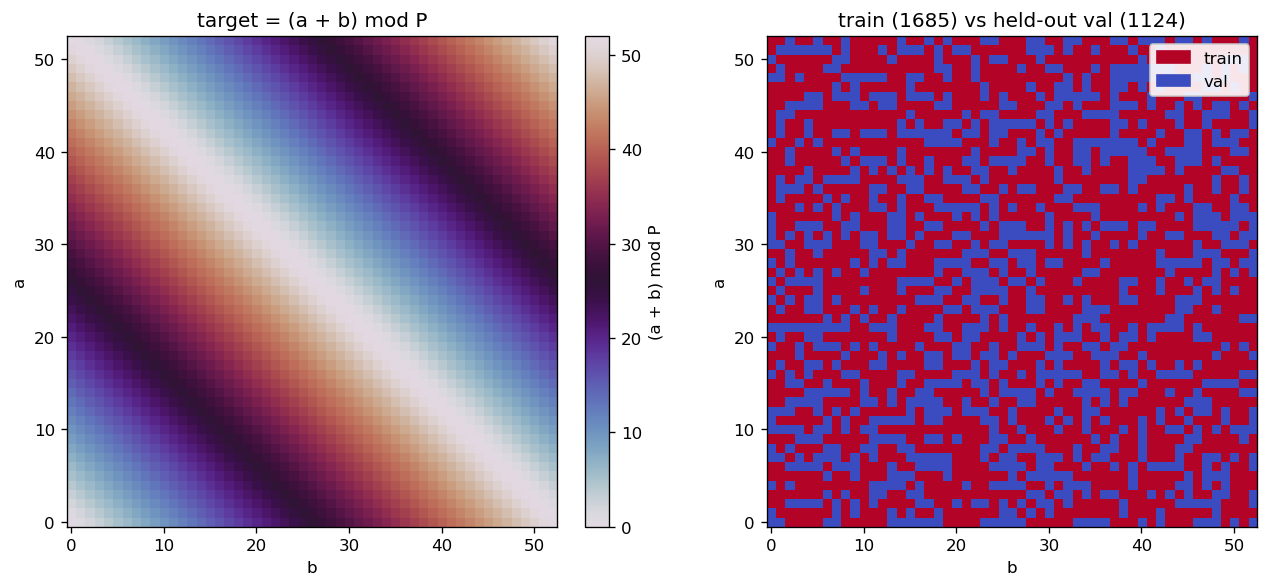

In [3]:
def plot_dataset(X_train, X_val, p=P):
    """Visualise the task as two p x p grids indexed by the inputs (a, b).

    Left:  the *full* lookup table the model must learn -- target = (a + b) % p.
           A cyclic colormap makes the wrap-around visible: the value increases
           along each anti-diagonal and jumps back to 0 when the sum passes p.
    Right: which (a, b) cells the model actually sees (train) vs. the ones held
           out for validation. The split is random, so generalising means
           recovering the diagonal rule on the left from a sparse sample.
    """
    from matplotlib.patches import Patch

    a = np.arange(p)
    table = (a[:, None] + a[None, :]) % p          # full ground-truth grid

    split = np.full((p, p), np.nan)                # 1 = train, 0 = val
    split[X_train[:, 0].numpy(), X_train[:, 1].numpy()] = 1
    split[X_val[:, 0].numpy(),   X_val[:, 1].numpy()]   = 0

    fig, ax = plt.subplots(1, 2, figsize=(11, 5), dpi=120)

    im = ax[0].imshow(table, cmap="twilight", origin="lower")
    ax[0].set_title("target = (a + b) mod P")
    ax[0].set_xlabel("b"); ax[0].set_ylabel("a")
    fig.colorbar(im, ax=ax[0], fraction=0.046, label="(a + b) mod P")

    ax[1].imshow(split, cmap="coolwarm", origin="lower", vmin=0, vmax=1)
    ax[1].set_title(f"train ({len(X_train)}) vs held-out val ({len(X_val)})")
    ax[1].set_xlabel("b"); ax[1].set_ylabel("a")
    ax[1].legend(
        handles=[Patch(color=plt.cm.coolwarm(1.0), label="train"),
                 Patch(color=plt.cm.coolwarm(0.0), label="val")],
        loc="upper right", framealpha=0.9,
    )
    fig.tight_layout()
    plt.show()


plot_dataset(X_train, X_val)

# Komentarz
Na lewym wykresie pokazano pełną tablicę wyników dla działania (a + b) mod P. Wynik zależy od sumy dwóch liczb i zawija się po przekroczeniu wartości P.

Na prawym wykresie pokazano podział danych na zbiór treningowy i walidacyjny. Model widzi tylko losowo wybrane pola treningowe, a na pozostałych ma sprawdzić, czy nauczył się ogólnej reguły dodawania modulo, a nie tylko zapamiętał przykłady.

### The model

Each integer is mapped to a learnable **embedding** of dimension
`hidden_dim = 128`. The two embeddings (for $a$ and $b$) are concatenated and
passed through a 2-layer MLP that outputs logits over the $p$ possible sums:

$$\operatorname{emb}(a)\;\Vert\;\operatorname{emb}(b)
\;\xrightarrow{\;W_1,\ \mathrm{ReLU}\;}\; h
\;\xrightarrow{\;W_2\;}\; \text{logits}\in\mathbb{R}^{p}.$$

### Exercise 1 — the forward pass
Implement `Model.forward`:
1. Look up the embeddings of the input integers (`x` has shape `(batch, 2)`) and
   flatten the two embeddings into a single vector of size `2 * hidden_dim`.
2. Apply `fc1` followed by a ReLU.
3. Apply `readout` to obtain the logits.

In [4]:
class Model(nn.Module):
    def __init__(self, hidden_dim=128, p=P):
        super().__init__()
        self.embedding = nn.Embedding(p, hidden_dim)
        self.fc1 = nn.Linear(2 * hidden_dim, hidden_dim)
        self.readout = nn.Linear(hidden_dim, p)

    def forward(self, x):
        emb = self.embedding(x)              # (batch, 2, hidden_dim)
        emb = emb.view(emb.shape[0], -1)     # (batch, 2 * hidden_dim)
    
        h = torch.relu(self.fc1(emb))
        logits = self.readout(h)
    
        return logits


# Quick shape check (uncomment after implementing Exercise 1):
# logits = Model()(X_train[:4])
# print(logits.shape)  # expected: torch.Size([4, 53])

In [5]:
logits = Model()(X_train[:4])
print(logits.shape)

torch.Size([4, 53])


### Training: memorization vs generalization

We train **full-batch** (the whole training set is one batch) with cross-entropy
loss. After every step we record train/val loss and accuracy. The two quantities
to watch are:
- **train accuracy** → reaches 100% quickly (the model *memorizes*).
- **val accuracy** → may stay near chance ($\approx 1/p$) for a long time, then
  jump to 100% (*grokking*).

### Exercise 2 — the optimization step
Fill in the single gradient step inside the loop: zero the gradients, forward
pass on the training batch, compute the cross-entropy loss, backward, optimizer
step. The metrics block below your code expects you to have defined the variables
`logits` and `loss`.

In [6]:
@torch.no_grad()
def evaluate(model, X, y, criterion):
    logits = model(X)
    loss = criterion(logits, y).item()
    acc = (logits.argmax(dim=1) == y).float().mean().item() * 100
    return loss, acc


def train_model(model, optimizer, data, num_epochs, progress=True):
    """Full-batch training loop. Returns a history dict of per-epoch metrics."""
    X_train, y_train, X_val, y_val = data
    criterion = nn.CrossEntropyLoss()
    history = {k: [] for k in ("epoch", "train_loss", "train_acc", "val_loss", "val_acc")}

    epochs = tqdm.trange(num_epochs) if progress else range(num_epochs)
    for epoch in epochs:
        # --- TODO: Exercise 2 ---
        optimizer.zero_grad()

        logits = model(X_train)
        
        loss = criterion(logits, y_train)
        
        loss.backward()
        
        optimizer.step()
        # --- End Exercise 2 ---

        with torch.no_grad():
            train_loss = loss.item()
            train_acc = (logits.argmax(dim=1) == y_train).float().mean().item() * 100
            val_loss, val_acc = evaluate(model, X_val, y_val, criterion)

        for k, v in zip(history, (epoch, train_loss, train_acc, val_loss, val_acc)):
            history[k].append(v)

    return history

`plot_history` draws train/val loss and accuracy against epochs. The epoch axis
is log-scaled (and we shift by +1 so epoch 0 is visible) — grokking spans orders
of magnitude in time, so a linear axis would hide it.

In [7]:
def plot_history(history, title=""):
    epochs = np.array(history["epoch"]) + 1  # +1 so epoch 0 shows on a log axis
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(7, 6), dpi=120)

    ax[0].plot(epochs, history["train_loss"], label="train")
    ax[0].plot(epochs, history["val_loss"], label="val")
    ax[0].set_ylabel("loss")
    ax[0].set_yscale("log")
    ax[0].legend()

    ax[1].plot(epochs, history["train_acc"], label="train")
    ax[1].plot(epochs, history["val_acc"], label="val")
    ax[1].set_ylabel("accuracy (%)")
    ax[1].set_xlabel("epoch")
    ax[1].axhline(100, color="gray", lw=0.5, ls=":")
    ax[1].legend()

    ax[0].set_xscale("log")
    if title:
        ax[0].set_title(title)
    fig.tight_layout()
    plt.show()

### Watch the model grok

Train with **AdamW**, a small weight decay (`3e-2`) and learning rate `3e-2`. On
the log-scaled epoch axis you should see train accuracy hit 100% early while val
accuracy lingers near chance, then snap up to 100% much later — the signature
grokking curve.

> Full-batch training for several thousand epochs takes ~1–3 minutes on CPU. The
> dataset and model are tiny, so each epoch is cheap; the epochs are just many.

100%|██████████████████████████████████████████████████████████████████████████████| 8000/8000 [02:02<00:00, 65.32it/s]


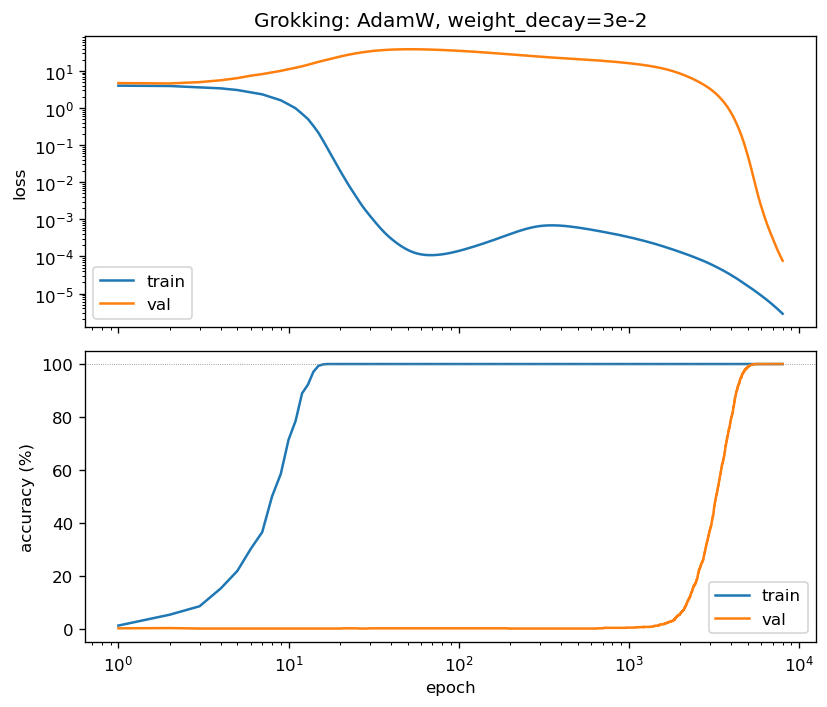

In [8]:
NUM_EPOCHS = 8000
data = make_data()

torch.manual_seed(0)
grok_model = Model(hidden_dim=128)
grok_opt = torch.optim.AdamW(grok_model.parameters(), lr=3e-2, weight_decay=3e-2)
grok_history = train_model(grok_model, grok_opt, data, NUM_EPOCHS)
plot_history(grok_history, title="Grokking: AdamW, weight_decay=3e-2")

# Komentarz
Na wykresie widać zjawisko grokkingu. Model bardzo szybko uczy się danych treningowych - dokładność treningowa osiąga prawie 100% już na początku. Dokładność walidacyjna długo pozostaje bliska zeru, czyli model na początku głównie zapamiętuje przykłady. Dopiero po wielu epokach accuracy na walidacji gwałtownie rośnie do 100%, co oznacza, że model odkrył ogólną regułę dodawania modulo.

### Exercise 3 — comprehension vs grokking
Train the **same** model/optimizer setup but with a *large* weight decay
(`weight_decay=5`). Plot the curve and compare it with Experiment 1.

Then answer:
- How does the train/val accuracy gap over epochs differ between `wd=3e-2` and
  `wd=5`?
- Why does *stronger* weight decay *remove* the grokking delay?
- What happens with `weight_decay=0`? Try it.

100%|██████████████████████████████████████████████████████████████████████████████| 8000/8000 [02:00<00:00, 66.40it/s]


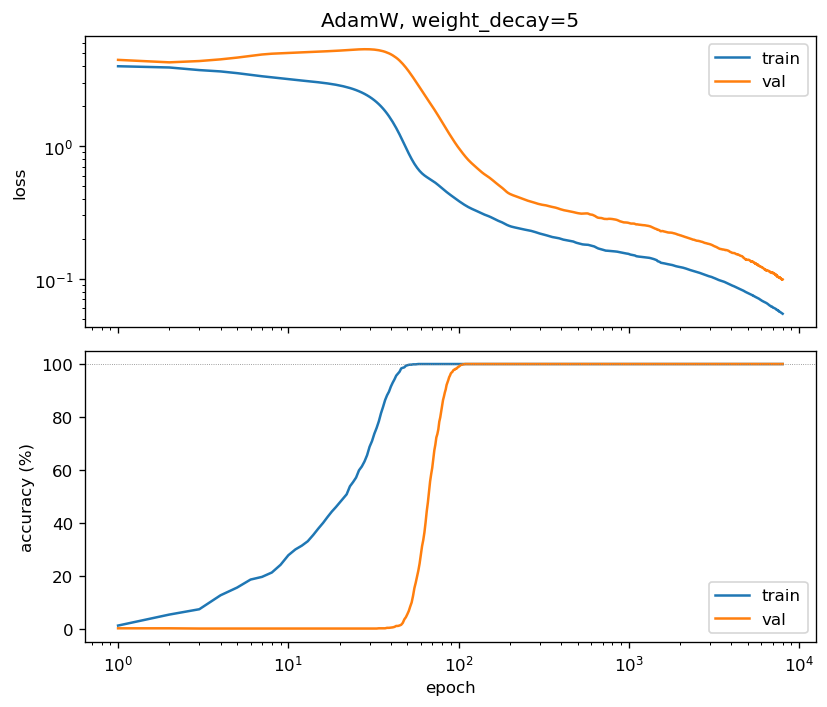

In [11]:
torch.manual_seed(0)

wd5_model = Model(hidden_dim=128)
wd5_opt = torch.optim.AdamW(
    wd5_model.parameters(),
    lr=3e-2,
    weight_decay=5
)

wd5_history = train_model(
    wd5_model,
    wd5_opt,
    data,
    NUM_EPOCHS
)

plot_history(wd5_history, title="AdamW, weight_decay=5")

# Komentarz
Przy dużym weight decay model szybciej zaczyna generalizować. Dokładność treningowa rośnie do 100%, a walidacyjna dochodzi do 100% niedługo później. Różnica między uczeniem a walidacją jest więc dużo mniejsza niż przy weight_decay=3e-2.

100%|██████████████████████████████████████████████████████████████████████████████| 8000/8000 [01:53<00:00, 70.48it/s]


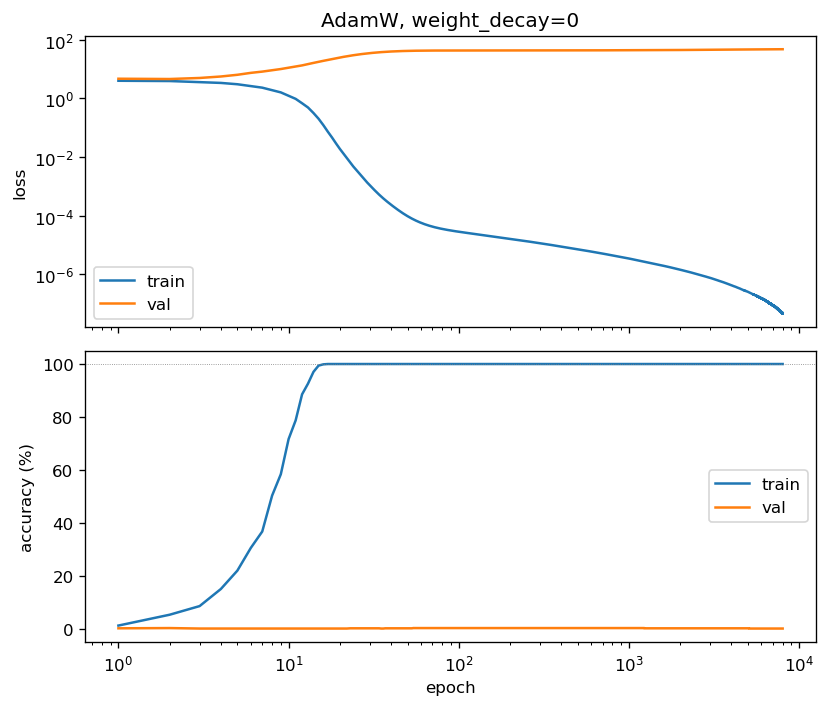

In [12]:
torch.manual_seed(0)

wd0_model = Model(hidden_dim=128)
wd0_opt = torch.optim.AdamW(
    wd0_model.parameters(),
    lr=3e-2,
    weight_decay=0
)

wd0_history = train_model(
    wd0_model,
    wd0_opt,
    data,
    NUM_EPOCHS
)

plot_history(wd0_history, title="AdamW, weight_decay=0")

# Komentarz
Dla weight_decay=0 model bardzo szybko zapamiętuje zbiór treningowy. Widać, że train loss spada prawie do zera, a train accuracy dochodzi do 100%. Jednocześnie val loss rośnie, a val accuracy zostaje blisko 0%, więc model nie generalizuje na dane walidacyjne.

Oznacza to, że bez regularizacji model uczy się głównie konkretnych przykładów treningowych, zamiast odkryć regułę dodawania modulo. W tym przypadku nie pojawia się grokking, ponieważ walidacja nie osiąga wysokiej dokładności nawet po wielu epokach.

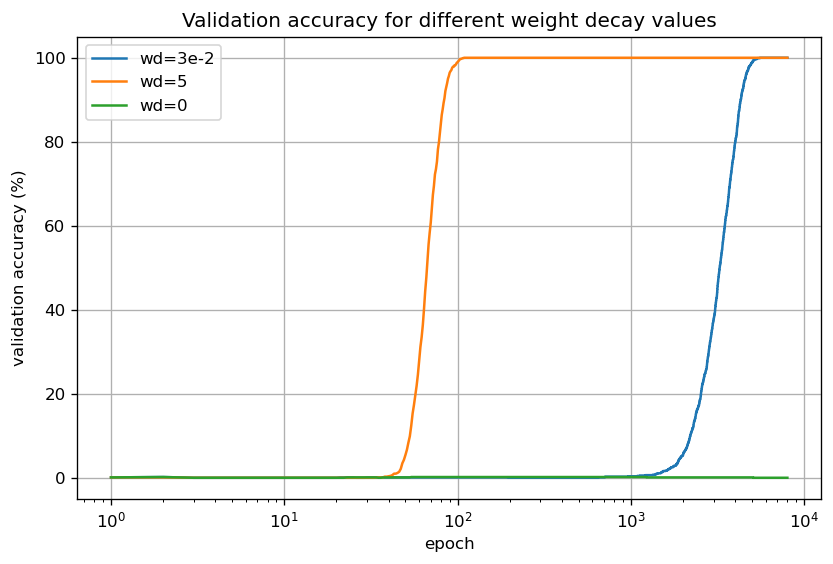

In [13]:
plt.figure(figsize=(8, 5), dpi=120)

epochs = np.array(grok_history["epoch"]) + 1

plt.plot(epochs, grok_history["val_acc"], label="wd=3e-2")
plt.plot(epochs, wd5_history["val_acc"], label="wd=5")
plt.plot(epochs, wd0_history["val_acc"], label="wd=0")

plt.xscale("log")
plt.xlabel("epoch")
plt.ylabel("validation accuracy (%)")
plt.title("Validation accuracy for different weight decay values")
plt.legend()
plt.grid(True)
plt.show()

# Komentarz
Na wykresie widać, że weight_decay=5 daje szybkie przejście walidacji do 100%, więc usuwa długie opóźnienie grokkingu. Dla weight_decay=3e-2 walidacja długo pozostaje niska i dopiero później gwałtownie rośnie. Dla weight_decay=0 walidacja praktycznie nie rośnie, więc model najpewniej zapamiętał dane treningowe, ale nie odkrył ogólnej reguły.

### Measuring the grokking gap

To compare runs quantitatively we define two events:
- **memorize@** — first epoch where train accuracy $\geq 99\%$.
- **grok@** — first epoch where val accuracy $\geq 90\%$.

The **grokking gap** is `grok@ - memorize@`: the number of epochs the model spends
"stuck" having memorized but not yet generalized.

### Exercise 4 — `first_epoch_reaching`
Implement a helper that returns the first epoch index at which a metric series
reaches a threshold (or `None` if it never does), then report `memorize@`,
`grok@`, and the gap for your grokking run.

In [14]:
def first_epoch_reaching(values, threshold):
    """Return the first index i where values[i] >= threshold, else None."""
    for i, value in enumerate(values):
        if value >= threshold:
            return i
    return None

In [15]:
mem = first_epoch_reaching(grok_history["train_acc"], 99.0)
grok = first_epoch_reaching(grok_history["val_acc"], 90.0)

print(f"memorize@{mem}  grok@{grok}  gap={grok - mem}")

memorize@14  grok@4294  gap=4280


In [16]:
for name, hist in [
    ("wd=3e-2", grok_history),
    ("wd=5", wd5_history),
    ("wd=0", wd0_history),
]:
    mem = first_epoch_reaching(hist["train_acc"], 99.0)
    grok = first_epoch_reaching(hist["val_acc"], 90.0)

    if mem is not None and grok is not None:
        gap = grok - mem
    else:
        gap = None

    print(f"{name}: memorize@{mem}, grok@{grok}, gap={gap}")

wd=3e-2: memorize@14, grok@4294, gap=4280
wd=5: memorize@48, grok@83, gap=35
wd=0: memorize@14, grok@None, gap=None


# Komentarz
Grokking Gap -okres czasu (mierzony w epokach), w którym model idealnie zapamiętał dane treningowe, ale wciąż nie potrafi poprawnie działać na nowych danych testowych.

Dla wd=3e-2 model zapamiętał dane w epoce 14, ale zaczął dobrze generalizować dopiero w epoce 4294, więc luka grokkingu wynosi 4280 epok. Dla wd=5 zapamiętanie nastąpiło w epoce 48, a generalizacja w epoce 83, więc luka wynosi tylko 35 epok. Dla wd=0 model zapamiętał trening w epoce 14, ale walidacja nie osiągnęła 90%, więc nie wystąpił pełny grokking.

Podane wyniki potwierdzają wizualizacje prezentowane wyżej.

### Does the optimizer affect grokking?

Train the **same** model (identical initialization and data split) with several
optimizers and watch the grokking gap. To make it a fair comparison we hold weight
decay fixed at `1e-3` and tune each learning rate so that every run memorizes
within ~50 epochs — the only thing left to differ is how long weight decay then
takes to push the model from memorizing to generalizing.

A `build_optimizer` helper and a list of tuned configs are provided below.

### Exercise 5
For each config: clone the shared initial weights, build the optimizer, train, and
record the history. Then **(a)** print a table of `memorize@`, `grok@`, gap, and
final val accuracy, and **(b)** plot val accuracy vs epoch (log x-axis) for all
optimizers on one figure.

Pay attention to **AdamW with `wd=1e-3`**: its weight decay is *decoupled* from the
adaptive update, so at this nominal value it is far too weak to pull the model out
of memorization — val accuracy stays near chance and it never groks within the
horizon. Bumping it to `wd=3e-2` recovers grokking. The lesson: what drives
grokking is the *effective* amount of regularization, not the nominal
weight-decay number — and that depends on the optimizer.

In [17]:
def build_optimizer(name, params, lr, weight_decay):
    """Construct an optimizer by name; all variants accept weight decay so the
    optimizer is the only thing changing between runs."""
    name = name.lower()
    if name == "adamw":     # decoupled weight decay
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    if name == "adam":      # L2 weight decay folded into the gradient
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "momentum":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(f"unknown optimizer: {name!r}")


WD = 1e-3
CONFIGS = [
    ("SGD",             "sgd",      10.0,  WD),
    ("SGD + momentum",  "momentum",  1.0,  WD),
    ("Adam",            "adam",      1e-3, WD),
    ("AdamW (wd=1e-3)", "adamw",     3e-2, WD),
    ("AdamW (wd=3e-2)", "adamw",     3e-2, 3e-2),
]

# Shared initial weights so the optimizer is the only thing that differs.
torch.manual_seed(0)
init_state = copy.deepcopy(Model(hidden_dim=128).state_dict())

In [18]:
import pandas as pd

optimizer_histories = {}
optimizer_results = []

NUM_EPOCHS_OPT = 8000

for label, opt_name, lr, wd in CONFIGS:
    print(f"Training: {label}")

    model = Model(hidden_dim=128)
    model.load_state_dict(copy.deepcopy(init_state))

    optimizer = build_optimizer(
        opt_name,
        model.parameters(),
        lr=lr,
        weight_decay=wd
    )

    history = train_model(
        model,
        optimizer,
        data,
        NUM_EPOCHS_OPT,
        progress=True
    )

    optimizer_histories[label] = history

    mem = first_epoch_reaching(history["train_acc"], 99.0)
    grok = first_epoch_reaching(history["val_acc"], 90.0)

    if mem is not None and grok is not None:
        gap = grok - mem
    else:
        gap = None

    optimizer_results.append({
        "optimizer": label,
        "memorize@": mem,
        "grok@": grok,
        "gap": gap,
        "final_val_acc": history["val_acc"][-1]
    })

optimizer_df = pd.DataFrame(optimizer_results)
optimizer_df

Training: SGD


100%|██████████████████████████████████████████████████████████████████████████████| 8000/8000 [01:48<00:00, 73.65it/s]


Training: SGD + momentum


100%|██████████████████████████████████████████████████████████████████████████████| 8000/8000 [01:55<00:00, 69.02it/s]


Training: Adam


...

Training: AdamW (wd=1e-3)


100%|██████████████████████████████████████████████████████████████████████████████| 8000/8000 [01:54<00:00, 69.88it/s]


Training: AdamW (wd=3e-2)


100%|██████████████████████████████████████████████████████████████████████████████| 8000/8000 [01:54<00:00, 70.15it/s]


,optimizer,memorize@,grok@,gap,final_val_acc
0,SGD,34,256.0,222.0,100.0
1,SGD + momentum,32,379.0,347.0,100.0
2,Adam,139,1380.0,1241.0,100.0
3,AdamW (wd=1e-3),14,NaN,NaN,0.0
4,AdamW (wd=3e-2),14,4294.0,4280.0,100.0


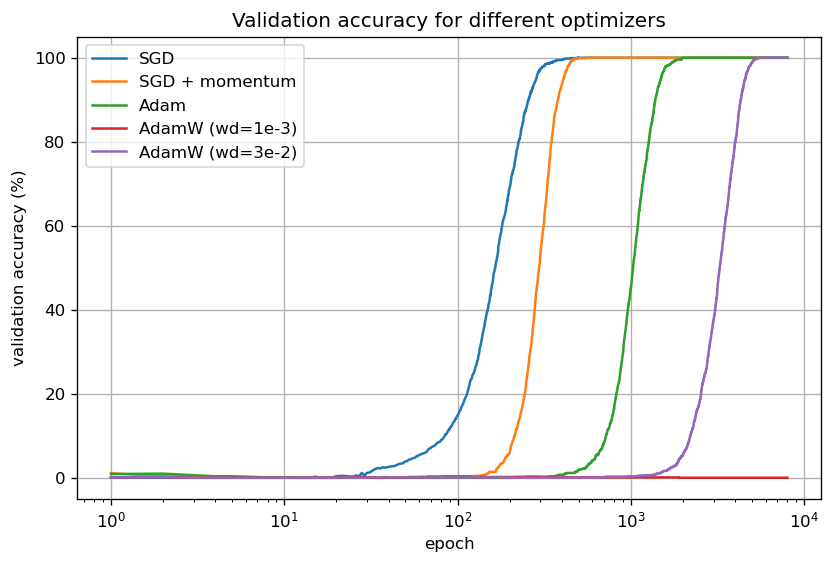

In [19]:
plt.figure(figsize=(8, 5), dpi=120)

for label, history in optimizer_histories.items():
    epochs = np.array(history["epoch"]) + 1
    plt.plot(epochs, history["val_acc"], label=label)

plt.xscale("log")
plt.xlabel("epoch")
plt.ylabel("validation accuracy (%)")
plt.title("Validation accuracy for different optimizers")
plt.legend()
plt.grid(True)
plt.show()

# Komentarz
Wyniki pokazują, że wybór optymalizatora mocno wpływa na szybkość grokkingu. Najszybciej zaczął generalizować zwykły SGD - osiągnął grok@256, a luka grokkingu wyniosła 222 epoki. SGD z momentum również osiągnął 100% walidacji, ale trochę później, z luką 347 epok.

Adam potrzebował więcej czasu na generalizację - grok@1380, więc jego luka była dużo większa i wyniosła 1241 epok. AdamW z małym weight_decay=1e-3 w ogóle nie zgrokował w czasie treningu, dlatego grok@ i gap mają wartość NaN; nie jest to błąd kodu, tylko oznacza brak osiągnięcia 90% walidacji. Dopiero AdamW z większym weight_decay=3e-2 osiągnął 100% walidacji, ale bardzo późno, z największą luką 4280.

Wniosek jest taki, że grokking zależy nie tylko od wartości weight decay, ale też od optymalizatora. Ten sam nominalny weight decay może działać różnie. Na wykresie widać, że wszystkie skuteczne optymalizatory ostatecznie dochodzą do 100% walidacji, ale robią to w bardzo różnym czasie.

### Questions
1. Grokking is described as "delayed generalization". In terms of the train/val
   loss and accuracy curves, what *exactly* is delayed, and relative to what?
2. Weight decay is the knob here. Explain mechanistically why shrinking the weight
   norm can turn a memorizing solution into a generalizing one.
3. Is grokking specific to this MLP, or to modular addition? What would you change
   to test that?

### Recommended reading
1. Power, Burda, Edwards, Babuschkin, Misra. [Grokking: Generalization Beyond
   Overfitting on Small Algorithmic Datasets](https://arxiv.org/abs/2201.02177)
   (2022).
2. Liu, Kitouni, Nolte, et al. Towards Understanding Grokking: An Effective Theory
   of Representation Learning: [blog](https://www.neelnanda.io/grokking-paper), [paper](https://arxiv.org/abs/2205.10343) (2022).
3. Nanda, Chan, Lieberum, Smith, Steinhardt. [Progress Measures for Grokking via
   Mechanistic Interpretability](https://arxiv.org/abs/2301.05217) (2023).
4. Li, Xu, Taylor, Studer, Goldstein. [Visualizing the Loss Landscape of Neural
   Nets](https://arxiv.org/abs/1712.09913)
5. Liu, Michaud, Tegmark [Omnigrok: Grokking Beyond Algorithmic Data](https://arxiv.org/pdf/2210.01117)

# Odpowiedzi
### Co jest opóźnione w grokkingu?
Opóźniona jest generalizacja, czyli wzrost dokładności walidacyjnej. Model dużo wcześniej osiąga prawie 100% accuracy na treningu, ale przez długi czas nie radzi sobie na walidacji. Dopiero później validation accuracy gwałtownie rośnie.

### Dlaczego weight decay pomaga?
Weight decay zmniejsza normę wag, więc utrudnia modelowi trzymanie skomplikowanego rozwiązania opartego tylko na zapamiętywaniu przykładów. Model jest wtedy wypychany w stronę prostszego rozwiązania, które lepiej opisuje prawdziwą regułę podanego problemu. Dlatego może przejść od memorization do generalization.

### Czy grokking zależy tylko od tego MLP albo dodawania modulo?
Nie musi być ograniczony tylko do tego modelu. Żeby to sprawdzić, można zmienić architekturę, np. liczbę warstw. Można też przetestować inne zadania, np. permutacje. Jeśli podobne opóźnione uogólnianie pojawi się też tam, to znaczy, że zjawisko jest szersze niż tylko ten konkretny MLP.